<a href="https://colab.research.google.com/github/MayankAsutkar/DATA_SCIENCE_AND_ML_PROJECTS/blob/main/Regression/Advertising_sales_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advertising_sales_prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('/content/drive/MyDrive/DATA_SCIENCE_ML_PROJECTS/Regression/Advertising.csv')

In [4]:
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [5]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [6]:
df.shape

(200, 4)

In [7]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [9]:
## no null values

# Understanding the Dataset

## Features
- TV
- Radio
- Newspaper
- Sales

## Independent Features (Input Variables)
- TV: Advertising budget spent on TV advertisements
- Radio: Advertising budget spent on radio advertisements
- Newspaper: Advertising budget spent on newspaper advertisements

## Dependent Feature (Target Variable)
- Sales: Product sales generated from the advertising campaigns

## Dataset Description
This dataset represents how investment across different advertising platforms affects the sales of a product.

The goal is to build a regression model that learns the relationship between advertising budgets and sales, and predicts future sales based on advertising expenditure.

## removing outliers

In [10]:
# IQR METHOD
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) |(df > (Q3 + 1.5 * IQR))).any(axis=1)]
df.shape

(198, 4)

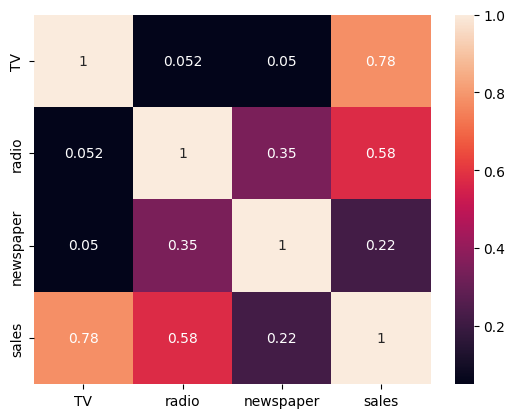

In [11]:
sns.heatmap(
    df.corr(),
    annot=True
)

plt.show()

In [12]:
## from the correlation status and heatmap we can state that the sales are heavily depended on TV ads folowing with radio and finally newspaper.
## these outpus means the sales are heavily influenced my modern advertisments compared to old methods like radio and newspaper.


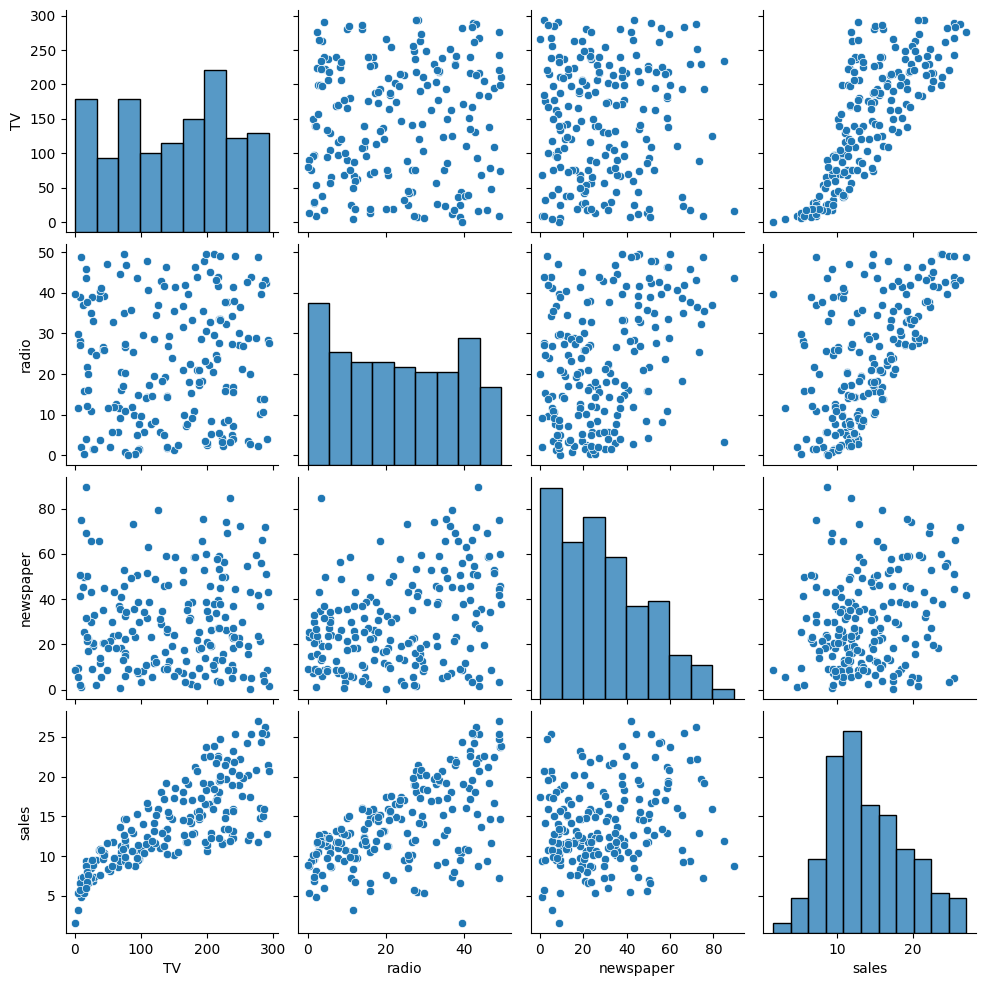

In [13]:
sns.pairplot(df)
plt.show()


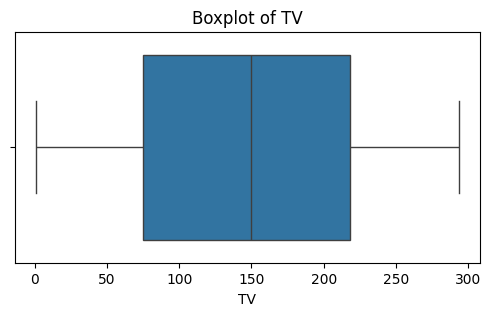

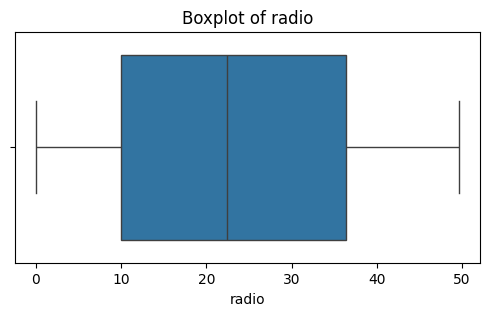

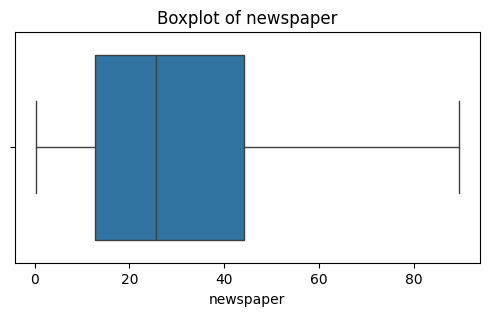

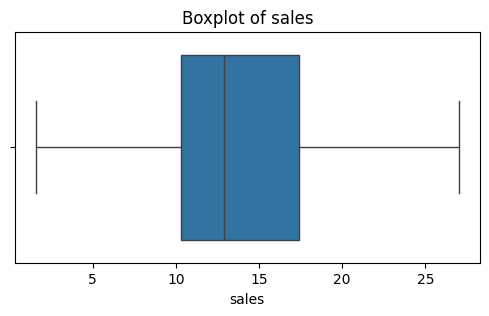

In [16]:
for col in df.columns:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

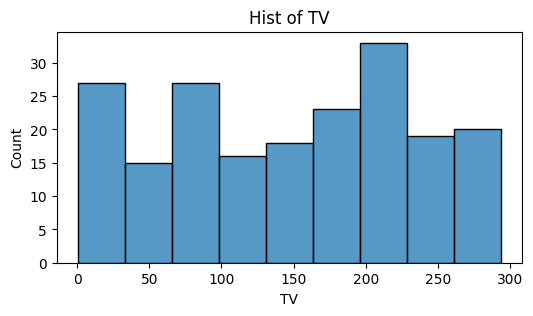

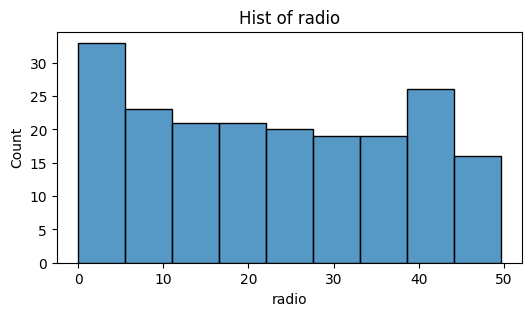

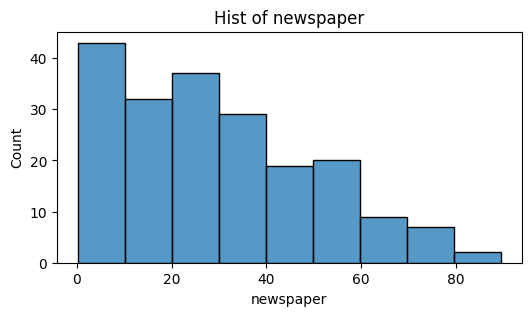

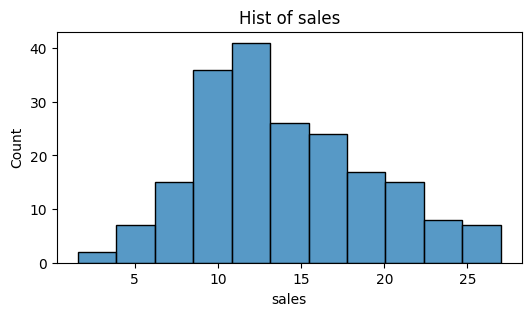

In [17]:
for col in df:
  plt.figure(figsize=(6, 3))
  sns.histplot(x=df[col])
  plt.title(f"Hist of {col}")
  plt.show()

In [18]:
## now we starting with prediction model


In [20]:
X = df[['TV','radio','newspaper']]
y = df['sales']


In [21]:
## Train test split
from sklearn.model_selection import train_test_split

In [23]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state = 42)

In [24]:
X_train.shape

(148, 3)

In [25]:
X_train.head()

,TV,radio,newspaper
187,191.1,28.7,18.2
43,206.9,8.4,26.4
68,237.4,27.5,11.0
195,38.2,3.7,13.8
76,27.5,1.6,20.7


In [27]:
### Standardization

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
### applyng linear regression

from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [29]:
regression.fit(X_train,y_train)

LinearRegression()

<Axes: xlabel='TV', ylabel='sales'>

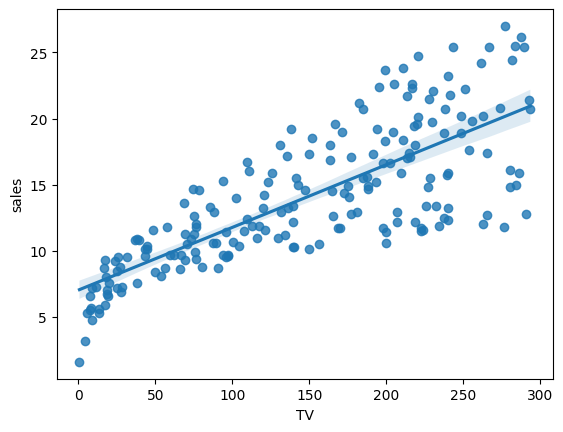

In [33]:
sns.regplot(x = 'TV',y = 'sales',data = df)


<Axes: xlabel='radio', ylabel='sales'>

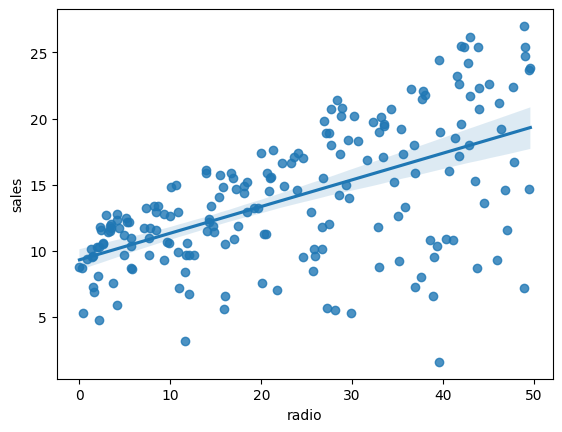

In [34]:
sns.regplot(x = 'radio',y = 'sales',data = df)

<Axes: xlabel='newspaper', ylabel='sales'>

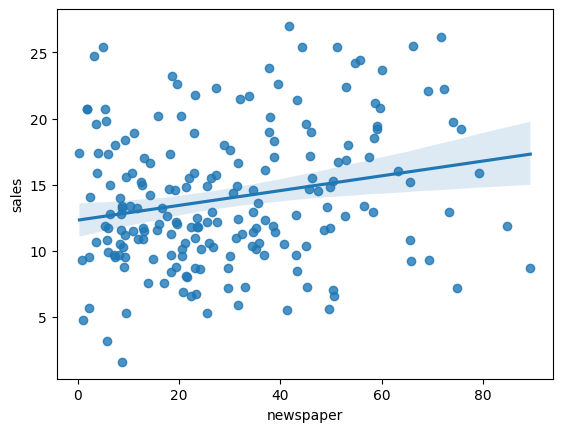

In [35]:
sns.regplot(x = 'newspaper',y = 'sales',data = df)

In [36]:
### prediction for the test data
y_pred = regression.predict(X_test)

In [37]:
y_pred

array([ 8.82290426, 11.99404595, 23.24778757,  9.01656412, 10.73423275,
       21.59566353, 19.17174836, 11.56398326, 14.01461825, 17.47252564,
       14.21787   , 20.89361395,  8.89129736, 12.63866464,  6.633081  ,
        9.14030126, 10.99478302, 12.48101233,  9.85695697, 11.50053326,
       13.27849821, 16.92635269, 22.91172162,  6.25458418, 16.97916635,
       20.81888944,  8.34849324, 14.9646917 ,  6.98084301, 12.30018944,
       17.76573789, 13.60775961,  6.58385423, 14.49375646, 15.40438234,
       17.96934561, 15.1813038 , 11.80870562, 18.27584621, 16.06026726,
       19.08858763, 13.16365279, 11.83902037,  9.42339259,  6.41229174,
        7.66803884, 17.05978143, 16.05357545, 11.20335949, 22.72669955])

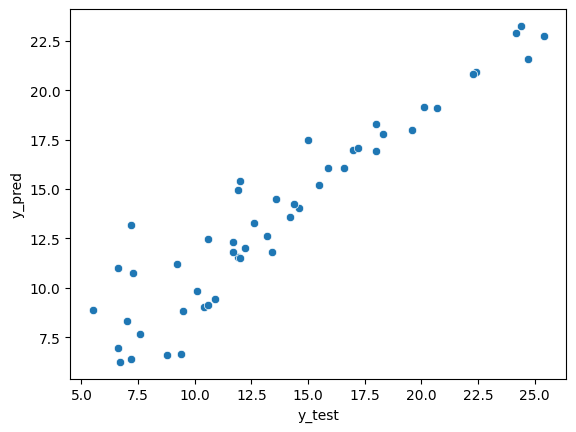

In [39]:
sns.scatterplot(x = y_test,y = y_pred)
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.show()

In [40]:
residual = y_pred - y_test

In [41]:
residual

,sales
66,-0.677096
116,-0.205954
17,-1.152212
143,-1.383436
158,3.434233
128,-3.104336
142,-0.928252
31,-0.336017
19,-0.585382
169,2.472526


In [42]:
## preformance metrics

In [45]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

score = r2_score(y_test,y_pred)
print(score)

## display adjusted R-squared
print(1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1] - 1))

3.454680474877475
1.3700158302961694
1.8586770765459704
0.8798818054597369
0.8720480101636328


In [46]:
## OlS linear Regression
!pip install statsmodels
import statsmodels.api as sm

In [52]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

model = sm.OLS(y_train, X_train_sm).fit()

prediction = model.predict(X_test_sm)

print(prediction)

[ 8.82290426 11.99404595 23.24778757  9.01656412 10.73423275 21.59566353
 19.17174836 11.56398326 14.01461825 17.47252564 14.21787    20.89361395
  8.89129736 12.63866464  6.633081    9.14030126 10.99478302 12.48101233
  9.85695697 11.50053326 13.27849821 16.92635269 22.91172162  6.25458418
 16.97916635 20.81888944  8.34849324 14.9646917   6.98084301 12.30018944
 17.76573789 13.60775961  6.58385423 14.49375646 15.40438234 17.96934561
 15.1813038  11.80870562 18.27584621 16.06026726 19.08858763 13.16365279
 11.83902037  9.42339259  6.41229174  7.66803884 17.05978143 16.05357545
 11.20335949 22.72669955]


In [53]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     416.1
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           1.03e-70
Time:                        20:05:04   Log-Likelihood:                -283.75
No. Observations:                 148   AIC:                             575.5
Df Residuals:                     144   BIC:                             587.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.0696      0.137    102.582      0.0

In [50]:
print(regression.coef_)
print(regression.intercept_)

[3.75075569 2.72801545 0.26189908]
14.069594594594596
